In [ ]:
from tensorflow.keras.datasets import mnist

In [ ]:
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
train_images.shape

(60000, 28, 28)

In [ ]:
test_images.shape

(10000, 28, 28)

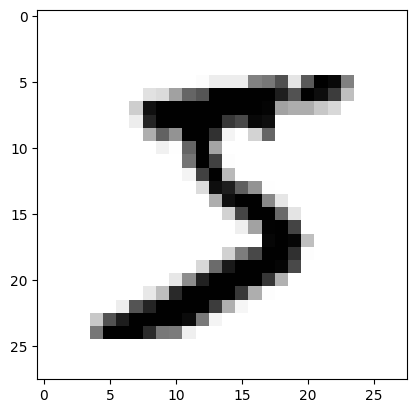

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(train_images[0], cmap=plt.cm.binary)
plt.show()

In [ ]:
print(train_labels[0])

5


In [ ]:
from keras import models
from keras import layers

network = models.Sequential()
network.add(layers.Dense(16, activation='relu', input_shape=(28 * 28,)))
network.add(layers.Dense(16, activation='relu'))
network.add(layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
network.compile(optimizer='rmsprop',
    loss='categorical_crossentropy',
    metrics=['accuracy'])

In [ ]:
network.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │        12,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,002 (50.79 KB)

 Trainable params: 13,002 (50.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
trn_images = train_images.reshape((60000, 28 * 28))
trn_images = trn_images.astype('float32') / 255
tst_images = test_images.reshape((10000, 28 * 28))
tst_images = tst_images.astype('float32') / 255

In [ ]:
from tensorflow.keras.utils import to_categorical
trn_labels = to_categorical(train_labels)
tst_labels = to_categorical(test_labels)

In [ ]:
trn_labels[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

In [ ]:
network.fit(trn_images, trn_labels, epochs=100, batch_size=256)

Epoch 1/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7261 - loss: 0.9081
Epoch 2/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9035 - loss: 0.3389
Epoch 3/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9189 - loss: 0.2813
Epoch 4/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9276 - loss: 0.2504
Epoch 5/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9334 - loss: 0.2283
Epoch 6/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9382 - loss: 0.2127
Epoch 7/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9415 - loss: 0.2001
Epoch 8/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9448 - loss: 0.1907
Epoch 9/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9473 - loss: 0.1820
Epoch 10/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9481 - loss: 0.1759
Epoch 11/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9502 - loss: 0.1706
Epoch 12/100
235/235 ━━━━━━━━━━━━━━━━━━━━

In [ ]:
test_loss, test_acc = network.evaluate(tst_images, tst_labels)
print('test_acc:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9485 - loss: 0.1942
test_acc: 0.9484999775886536


In [ ]:
import numpy as np
# Classify single image
ret = network.predict(np.expand_dims(tst_images[0], 0))
np.argmax(ret)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step


np.int64(7)

In [ ]:
ret

array([[8.2789295e-09, 2.5913471e-10, 5.2330815e-05, 1.9756479e-03,
        2.4256480e-12, 2.9144991e-07, 7.7042155e-22, 9.9796909e-01,
        4.3649639e-08, 2.5641637e-06]], dtype=float32)

In [ ]:
test_labels[0]

np.uint8(7)

In [ ]:
network.save('mnist_model.h5')